In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Расшифровка колонок — MMM_MMM_Comptage

Данные: подсчёт транспортных средств на дорогах агломерации Монпелье (MMM).

**Сокращения в названиях колонок:**
- **MJA** = Moyenne Journalière Annuelle — среднесуточный трафик за год
- **JO** = Jours Ouvrables — рабочие дни
- **JOHVS** = Jours Ouvrables Hors Vacances Scolaires — рабочие дни вне школьных каникул
- **TCJ** = Tous les Jours — все дни (включая выходные и праздники)
- **PL** = Poids Lourds — грузовые ТС (фуры, грузовики)
- **HP** = Heure de Pointe — час пик
- **HPM** = Heure de Pointe Matin — утренний час пик
- **HPS** = Heure de Pointe Soir — вечерний час пик
- **HCJ** = Heure Creuse Jour — дневное межпиковое время
- **HCN** = Heure Creuse Nuit — ночное межпиковое время

---

## Идентификаторы и метаданные станции

| Колонка | Описание |
|---|---|
| `objectid` | Уникальный идентификатор записи |
| `id_centrale` | ID счётной станции |
| `code_centrale` | Код счётной станции |
| `libelle_centrale` | Название / описание местоположения счётной станции |
| `annee` | Год измерения |
| `libelle_groupage` | Метка группировки направлений (например, «Sens cumulés» = суммарный поток) |
| `label_sens_circu` | Метка направления движения (откуда → куда) |
| `type_compteur` | Тип счётчика: `compteur tournant` — переносной, `compteur feux` — на светофоре, `compteur ponctuel` — точечный |
| `type_comptage` | Тип подсчёта: `bidirectionnel` — двунаправленный, `unidirectionnel` — однонаправленный |
| `nb_canaux` | Количество каналов (полос/направлений) у данной станции |
| `list_canaux` | Список кодов каналов (0, 1 — направления; Z — сумма) |
| `nb_annee` | Количество лет, за которые есть данные по станции |
| `list_annee` | Список лет, за которые есть данные |
| `code_canal` | Код текущего канала (0 или 1 — конкретное направление, Z — суммарный поток) |
| `descriptif_periode` | Период измерения (дата начала — дата конца) |
| `time_days` | Продолжительность периода измерения в днях |

---

## Интенсивность потока (авт./сут.)

| Колонка | Описание |
|---|---|
| `mja_jo` | Среднесуточный трафик — рабочие дни |
| `mja_johvs` | Среднесуточный трафик — рабочие дни вне школьных каникул |
| `mja_tcj` | Среднесуточный трафик — все дни |
| `mja_pl_tcj` | Среднесуточный трафик грузовых ТС — все дни |
| `mja_pl_johvs` | Среднесуточный трафик грузовых ТС — рабочие дни вне школьных каникул |

---

## Часы пик (JOHVS)

| Колонка | Описание |
|---|---|
| `hp_johvs_matin` | Утренний час пик: интенсивность (авт./ч) и временной интервал, например `96 (11h30 - 12h30)` |
| `hp_johvs_soir` | Вечерний час пик: интенсивность (авт./ч) и временной интервал |

---

## Трафик по периодам суток (авт./ч, JOHVS)

| Колонка | Описание |
|---|---|
| `hpm_0709_johvs` | Утренний час пик 07:00–09:00 — все ТС |
| `hpm_pl_0709_johvs` | Утренний час пик 07:00–09:00 — грузовые ТС |
| `hcj_0916_johvs` | Дневное межпиковое время 09:00–16:00 — все ТС |
| `hcj_pl_0916_johvs` | Дневное межпиковое время 09:00–16:00 — грузовые ТС |
| `hps_1619_johvs` | Вечерний час пик 16:00–19:00 — все ТС |
| `hps_pl_1619_johvs` | Вечерний час пик 16:00–19:00 — грузовые ТС |
| `hcn_1907_johvs` | Ночное время 19:00–07:00 — все ТС |
| `hcn_pl_1907_johvs` | Ночное время 19:00–07:00 — грузовые ТС |

---

## Скорость и доля грузовых ТС (TCJ)

| Колонка | Описание |
|---|---|
| `tir_tcj` | Доля грузовых ТС в потоке, % — все дни |
| `v85ma_tcj` | Скорость 85-го перцентиля в утренний час пик, км/ч — все дни |
| `vtma_tcj` | Средняя скорость в утренний час пик, км/ч — все дни |

---

## Атрибуты дороги (OpenStreetMap)

| Колонка | Описание |
|---|---|
| `name` | Название улицы / дороги (из OSM) |
| `highway` | Тип дороги по классификации OSM (`primary`, `secondary`, `tertiary`, `residential` и др.) |
| `nom_commune` | Название коммуны (муниципалитета) |
| `osm_id` | Идентификатор объекта в OpenStreetMap |

In [45]:
!ls -a

.                  .gitignore         data_audit.ipynb   map_coverage.html
..                 .ipynb_checkpoints data_loading.ipynb
.DS_Store          .venv              geoloc_audit.ipynb
.git               data               gtfs_audit.ipynb


In [46]:
data = pd.read_csv("data/MMM_MMM_Comptage (1).csv")

## Column & value rename reference (FR → EN)

### Columns

| Original (FR) | English name | Notes |
|---|---|---|
| `objectid` | `object_id` | |
| `id_centrale` | `counter_station_id` | |
| `code_centrale` | `counter_station_code` | |
| `libelle_centrale` | `counter_station_name` | Road label + location |
| `annee` | `year` | |
| `libelle_groupage` | `section_label` | Cross-street grouping label |
| `label_sens_circu` | `direction_label` | Cross-street direction label |
| `type_compteur` | `counter_type` | See value map below |
| `type_comptage` | `counting_type` | See value map below |
| `nb_canaux` | `num_channels` | |
| `list_canaux` | `channel_list` | |
| `nb_annee` | `num_years` | |
| `list_annee` | `year_list` | |
| `code_canal` | `channel_code` | 0/1 = direction, Z = combined |
| `mja_jo` | `aadt_wd` | Mean annual daily traffic — working days |
| `mja_johvs` | `aadt_wd_nsh` | AADT — working days excl. school holidays |
| `mja_tcj` | `aadt_all` | AADT — all days |
| `mja_pl_tcj` | `aadt_hv_all` | AADT heavy vehicles — all days |
| `hp_johvs_matin` | `peak_hour_morning` | Morning peak hour volume (JOHVS) |
| `hp_johvs_soir` | `peak_hour_evening` | Evening peak hour volume (JOHVS) |
| `tir_tcj` | `tir_all` | Heavy-vehicle share (%) — all days |
| `v85ma_tcj` | `v85_all` | 85th-percentile speed km/h — all days |
| `vtma_tcj` | `vtma_all` | Mean speed km/h — all days |
| `mja_pl_johvs` | `aadt_hv_wd_nsh` | AADT heavy vehicles — JOHVS |
| `hpm_0709_johvs` | `vol_morning_0709` | Volume 07:00–09:00 — JOHVS |
| `hpm_pl_0709_johvs` | `vol_morning_hv_0709` | Heavy-vehicle volume 07:00–09:00 — JOHVS |
| `hcj_0916_johvs` | `vol_daytime_0916` | Volume 09:00–16:00 — JOHVS |
| `hcj_pl_0916_johvs` | `vol_daytime_hv_0916` | Heavy-vehicle volume 09:00–16:00 — JOHVS |
| `hps_1619_johvs` | `vol_evening_1619` | Volume 16:00–19:00 — JOHVS |
| `hps_pl_1619_johvs` | `vol_evening_hv_1619` | Heavy-vehicle volume 16:00–19:00 — JOHVS |
| `hcn_1907_johvs` | `vol_night_1907` | Volume 19:00–07:00 — JOHVS |
| `hcn_pl_1907_johvs` | `vol_night_hv_1907` | Heavy-vehicle volume 19:00–07:00 — JOHVS |
| `descriptif_periode` | `period_description` | Human-readable measurement window |
| `time_days` | `time_days` | *(unchanged)* |
| `name` | `road_name` | OSM road name |
| `highway` | `highway` | *(unchanged — already English OSM tag)* |
| `nom_commune` | `municipality` | |
| `osm_id` | `osm_id` | *(unchanged)* |

### Categorical values

**`counter_type`** (was `type_compteur`):

| FR | EN |
|---|---|
| `compteur ponctuel` | `spot` |
| `compteur ponctuel vélo` | `spot_bike` |
| `compteur permanent` | `permanent` |
| `compteur permanent vélo` | `permanent_bike` |
| `compteur tournant` | `rotating` |
| `compteur feux` | `traffic_light` |

**`counting_type`** (was `type_comptage`):

| FR | EN |
|---|---|
| `comptage bidirectionnel` | `bidirectional` |
| `comptage unidirectionnel` | `unidirectional` |
| `NR` | `NR` *(no change)* |

In [47]:
COLUMN_RENAME = {
    "objectid":            "object_id",
    "id_centrale":         "counter_station_id",
    "code_centrale":       "counter_station_code",
    "libelle_centrale":    "counter_station_name",
    "annee":               "year",
    "libelle_groupage":    "section_label",
    "label_sens_circu":    "direction_label",
    "type_compteur":       "counter_type",
    "type_comptage":       "counting_type",
    "nb_canaux":           "num_channels",
    "list_canaux":         "channel_list",
    "nb_annee":            "num_years",
    "list_annee":          "year_list",
    "code_canal":          "channel_code",
    "mja_jo":              "aadt_wd",
    "mja_johvs":           "aadt_wd_nsh",
    "mja_tcj":             "aadt_all",
    "mja_pl_tcj":          "aadt_hv_all",
    "hp_johvs_matin":      "peak_hour_morning",
    "hp_johvs_soir":       "peak_hour_evening",
    "tir_tcj":             "tir_all",
    "v85ma_tcj":           "v85_all",
    "vtma_tcj":            "vtma_all",
    "mja_pl_johvs":        "aadt_hv_wd_nsh",
    "hpm_0709_johvs":      "vol_morning_0709",
    "hpm_pl_0709_johvs":   "vol_morning_hv_0709",
    "hcj_0916_johvs":      "vol_daytime_0916",
    "hcj_pl_0916_johvs":   "vol_daytime_hv_0916",
    "hps_1619_johvs":      "vol_evening_1619",
    "hps_pl_1619_johvs":   "vol_evening_hv_1619",
    "hcn_1907_johvs":      "vol_night_1907",
    "hcn_pl_1907_johvs":   "vol_night_hv_1907",
    "descriptif_periode":  "period_description",
    "time_days":           "time_days",
    "name":                "road_name",
    "highway":             "highway",
    "nom_commune":         "municipality",
    "osm_id":              "osm_id",
}

COUNTER_TYPE_RENAME = {
    "compteur ponctuel":       "spot",
    "compteur ponctuel vélo":  "spot_bike",
    "compteur permanent":      "permanent",
    "compteur permanent vélo": "permanent_bike",
    "compteur tournant":       "rotating",
    "compteur feux":           "traffic_light",
}

COUNTING_TYPE_RENAME = {
    "comptage bidirectionnel":    "bidirectional",
    "comptage unidirectionnel":   "unidirectional",
    "NR":                         "NR",
}


def translate_to_english(df: pd.DataFrame) -> pd.DataFrame:
    """Rename columns and categorical values from French to English."""
    df = df.rename(columns=COLUMN_RENAME)
    if "counter_type" in df.columns:
        df["counter_type"] = df["counter_type"].map(COUNTER_TYPE_RENAME).fillna(df["counter_type"])
    if "counting_type" in df.columns:
        df["counting_type"] = df["counting_type"].map(COUNTING_TYPE_RENAME).fillna(df["counting_type"])
    return df


data = translate_to_english(data)
print("Columns after rename:", data.columns.tolist())
print("\ncounter_type values: ", data["counter_type"].unique())
print("counting_type values:", data["counting_type"].unique())

Columns after rename: ['object_id', 'counter_station_id', 'counter_station_code', 'counter_station_name', 'year', 'section_label', 'direction_label', 'counter_type', 'counting_type', 'num_channels', 'channel_list', 'num_years', 'year_list', 'channel_code', 'aadt_wd', 'aadt_wd_nsh', 'aadt_all', 'aadt_hv_all', 'peak_hour_morning', 'peak_hour_evening', 'tir_all', 'v85_all', 'vtma_all', 'aadt_hv_wd_nsh', 'vol_morning_0709', 'vol_morning_hv_0709', 'vol_daytime_0916', 'vol_daytime_hv_0916', 'vol_evening_1619', 'vol_evening_hv_1619', 'vol_night_1907', 'vol_night_hv_1907', 'period_description', 'time_days', 'road_name', 'highway', 'municipality', 'osm_id']

counter_type values:  <StringArray>
['rotating', 'traffic_light', 'spot', 'permanent', 'permanent_bike',
 'spot_bike']
Length: 6, dtype: str
counting_type values: <StringArray>
['bidirectional', 'unidirectional', 'NR']
Length: 3, dtype: str


# Column reference — MMM_MMM_Comptage (after rename)

Dataset: vehicle counts on roads of the Montpellier Méditerranée Métropole (MMM) area.

**Column name abbreviations:**
- **AADT** = Annual Average Daily Traffic (Moyenne Journalière Annuelle)
- **WD** = Working Days (Jours Ouvrables)
- **NSH** = No School Holidays (Hors Vacances Scolaires)
- **all** = All days including weekends and public holidays (Tous les Jours)
- **hv** = Heavy Vehicles (Poids Lourds)
- **vol** = Volume in veh/h for a fixed time window
- **0709 / 0916 / 1619 / 1907** = time window in hhmm format

---

## Station identifiers and metadata

| Column | Description |
|---|---|
| `object_id` | Unique row identifier |
| `counter_station_id` | Numeric ID of the counting station |
| `counter_station_code` | Alphanumeric code of the counting station |
| `counter_station_name` | Human-readable station label (road name + location) |
| `year` | Measurement year |
| `section_label` | Traffic section grouping label (cross-street pair, e.g. "Palavas_Comte Melgueil"; "Sens cumulés" = combined directions) |
| `direction_label` | Direction-level label (same vocabulary as `section_label`; equals `section_label` for unidirectional rows) |
| `counter_type` | Counter technology: `spot`, `permanent`, `rotating`, `traffic_light`, `spot_bike`, `permanent_bike` |
| `counting_type` | Counting method: `bidirectional` (both directions measured), `unidirectional` (one direction only), `NR` (not recorded) |
| `num_channels` | Number of measurement channels at the station (1 = unidirectional, 3 = bidirectional + combined) |
| `channel_list` | List of channel codes available for this station (e.g. `{0,1,Z}`) |
| `num_years` | Number of years for which data exist at this station |
| `year_list` | List of years for which data exist |
| `channel_code` | Channel code for this row: `0` or `1` = a single direction, `Z` = combined flow |
| `period_description` | Human-readable measurement window (e.g. "du 01/01/2023 au 31/12/2023") |
| `time_days` | Duration of the measurement period in days |

---

## Traffic flow (veh/day)

| Column | Description |
|---|---|
| `aadt_wd` | AADT — working days |
| `aadt_wd_nsh` | AADT — working days excl. school holidays |
| `aadt_all` | AADT — all days |
| `aadt_hv_all` | AADT heavy vehicles — all days |
| `aadt_hv_wd_nsh` | AADT heavy vehicles — working days excl. school holidays |

---

## Peak hours (working days excl. school holidays)

| Column | Description |
|---|---|
| `peak_hour_morning` | Morning peak: volume (veh/h) + time window, e.g. `96 (11h30 - 12h30)` |
| `peak_hour_evening` | Evening peak: volume (veh/h) + time window |

---

## Volume by time-of-day window (veh/h, working days excl. school holidays)

| Column | Description |
|---|---|
| `vol_morning_0709` | All vehicles — 07:00–09:00 |
| `vol_morning_hv_0709` | Heavy vehicles — 07:00–09:00 |
| `vol_daytime_0916` | All vehicles — 09:00–16:00 |
| `vol_daytime_hv_0916` | Heavy vehicles — 09:00–16:00 |
| `vol_evening_1619` | All vehicles — 16:00–19:00 |
| `vol_evening_hv_1619` | Heavy vehicles — 16:00–19:00 |
| `vol_night_1907` | All vehicles — 19:00–07:00 |
| `vol_night_hv_1907` | Heavy vehicles — 19:00–07:00 |

---

## Speed and heavy-vehicle share (all days)

| Column | Description |
|---|---|
| `tir_all` | Heavy-vehicle share in the traffic stream, % |
| `v85_all` | 85th-percentile speed during morning peak, km/h |
| `vtma_all` | Mean speed during morning peak, km/h |

---

## Road attributes (OpenStreetMap)

| Column | Description |
|---|---|
| `road_name` | Street / road name from OSM |
| `highway` | OSM highway tag (`primary`, `secondary`, `tertiary`, `residential`, etc.) |
| `municipality` | Municipality (commune) name |
| `osm_id` | OpenStreetMap way/node ID |

In [48]:
data.head()

,object_id,counter_station_id,counter_station_code,counter_station_name,year,section_label,direction_label,counter_type,counting_type,num_channels,channel_list,num_years,year_list,channel_code,aadt_wd,aadt_wd_nsh,aadt_all,aadt_hv_all,peak_hour_morning,peak_hour_evening,tir_all,v85_all,vtma_all,aadt_hv_wd_nsh,vol_morning_0709,vol_morning_hv_0709,vol_daytime_0916,vol_daytime_hv_0916,vol_evening_1619,vol_evening_hv_1619,vol_night_1907,vol_night_hv_1907,period_description,time_days,road_name,highway,municipality,osm_id
0,5629,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2026,Sens cumulés,Sens cumulés,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",Z,2070.0,2070.0,1920.0,11.0,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 12/03/2026 au 19/03/2026,7.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
1,5627,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2026,RM116E2_RM185,RM116E2_RM185,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",0,1473.0,1473.0,1306.0,5.0,96 (11h30 - 12h30),313 (17h15 - 18h15),21.0,74.0,61.0,6.0,45.0,1.0,75.0,0.0,236.0,0.0,13.0,0.0,du 12/03/2026 au 19/03/2026,7.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
2,5628,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2026,RM185_RM116E2,RM185_RM116E2,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",1,597.0,597.0,614.0,6.0,110 (7h45 - 8h45),48 (13h15 - 14h15),29.0,77.0,63.0,7.0,92.0,0.0,37.0,0.0,32.0,1.0,5.0,0.0,du 12/03/2026 au 19/03/2026,7.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
3,5637,972,100457,MONTPELLIER. Boulevard de Strasbourg,2026,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,unidirectional,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,754.0,779.0,671.0,NaN,113 (8h00 - 9h00),62 (17h00 - 18h00),NaN,NaN,NaN,NaN,79.0,NaN,39.0,NaN,56.0,NaN,15.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4,7505,83982,100580,MONTPELLIER. Rue des Bleuets,2026,Sens cumulés,Sens cumulés,spot,bidirectional,3,"{0,1,Z}",1,{2026},Z,249.0,249.0,228.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 10/02/2026 au 17/02/2026,7.0,Rue des Bleuets,residential,Montpellier,34201206


In [50]:
data[data["counter_station_id"] == 1198].sort_values(by="year")

,object_id,counter_station_id,counter_station_code,counter_station_name,year,section_label,direction_label,counter_type,counting_type,num_channels,channel_list,num_years,year_list,channel_code,aadt_wd,aadt_wd_nsh,aadt_all,aadt_hv_all,peak_hour_morning,peak_hour_evening,tir_all,v85_all,vtma_all,aadt_hv_wd_nsh,vol_morning_0709,vol_morning_hv_0709,vol_daytime_0916,vol_daytime_hv_0916,vol_evening_1619,vol_evening_hv_1619,vol_night_1907,vol_night_hv_1907,period_description,time_days,road_name,highway,municipality,osm_id
8497,5605,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2018,RM185_RM116E2,RM185_RM116E2,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",1,455.0,455.0,418.0,16.0,58 (7h30 - 8h30),36 (13h15 - 14h15),7.0,74.0,60.0,19.0,53.0,1.0,30.0,1.0,28.0,1.0,5.0,0.0,du 19/03/2018 au 07/08/2018,141.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
8495,5606,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2018,Sens cumulés,Sens cumulés,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",Z,1453.0,1453.0,1304.0,39.0,NaN,NaN,NaN,NaN,NaN,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 19/03/2018 au 07/08/2018,141.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
8496,5604,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2018,RM116E2_RM185,RM116E2_RM185,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",0,998.0,998.0,886.0,23.0,85 (11h30 - 12h30),199 (17h00 - 18h00),7.0,74.0,62.0,26.0,25.0,2.0,59.0,2.0,152.0,3.0,9.0,0.0,du 19/03/2018 au 07/08/2018,141.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
7754,5608,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2019,RM185_RM116E2,RM185_RM116E2,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",1,698.0,698.0,592.0,6.0,125 (7h30 - 8h30),59 (13h30 - 14h30),6.0,73.0,60.0,8.0,110.0,1.0,43.0,1.0,31.0,0.0,6.0,0.0,du 21/06/2019 au 27/11/2019,159.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
7753,5607,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2019,RM116E2_RM185,RM116E2_RM185,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",0,1483.0,1483.0,1262.0,11.0,119 (11h30 - 12h30),300 (17h15 - 18h15),5.0,73.0,60.0,14.0,43.0,1.0,80.0,1.0,224.0,2.0,15.0,0.0,du 21/06/2019 au 27/11/2019,159.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
7752,5609,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2019,Sens cumulés,Sens cumulés,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",Z,2181.0,2181.0,1854.0,17.0,NaN,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 21/06/2019 au 27/11/2019,159.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
6847,5611,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2020,RM185_RM116E2,RM185_RM116E2,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",1,587.0,587.0,615.0,13.0,124 (7h45 - 8h45),43 (13h45 - 14h45),17.0,81.0,64.0,6.0,98.0,1.0,36.0,0.0,31.0,0.0,3.0,0.0,du 05/03/2020 au 13/11/2020,253.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
6846,5610,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2020,RM116E2_RM185,RM116E2_RM185,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",0,1265.0,1265.0,1007.0,10.0,94 (11h30 - 12h30),243 (17h15 - 18h15),14.0,80.0,68.0,13.0,39.0,1.0,70.0,1.0,184.0,1.0,11.0,0.0,du 05/03/2020 au 13/11/2020,253.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
6845,5612,1198,100352,VILLENEUVE LES MAGUELONE. RM116 3131,2020,Sens cumulés,Sens cumulés,rotating,bidirectional,3,"{0,1,Z}",9,"{2018,2019,2020,2021,2022,2023,2024,2025,2026}",Z,1852.0,1852.0,1622.0,23.0,NaN,NaN,NaN,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 05/03/2020 au 13/11/2020,253.0,Chemin de la Rivière,tertiary,Villeneuve-lès-Maguelone,244106263
5911,5614,1198,100352,VI

#### Сколько всего уникальных сечений

In [17]:
data["osm_id"].nunique()

2081

#### Сколько всего записей

In [18]:
data.drop_duplicates().shape[0]

12211

#### Какая доля записей имеет непустой id_osm. Именно эта доля определяет, сколько постов мы сможем автоматически привязать к сети в модуле 4.

In [19]:
data["osm_id"].isna().sum()

np.int64(0)

#### Свежесть: распределение по годам измерения. Сколько сечений измерено после 2020 года? Данные 2013 года для калибровки на 2024-й использовать нельзя.

In [20]:
data["year"].value_counts()

year
2023    1683
2022    1360
2026    1160
2024    1065
2021     933
2020     910
2018     767
2019     743
2025     641
2017     596
2016     504
2013     409
2014     407
2015     395
2012     261
2010     225
2011     152
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '2010'),
  Text(1, 0, '2011'),
  Text(2, 0, '2012'),
  Text(3, 0, '2013'),
  Text(4, 0, '2014'),
  Text(5, 0, '2015'),
  Text(6, 0, '2016'),
  Text(7, 0, '2017'),
  Text(8, 0, '2018'),
  Text(9, 0, '2019'),
  Text(10, 0, '2020'),
  Text(11, 0, '2021'),
  Text(12, 0, '2022'),
  Text(13, 0, '2023'),
  Text(14, 0, '2024'),
  Text(15, 0, '2025'),
  Text(16, 0, '2026')])

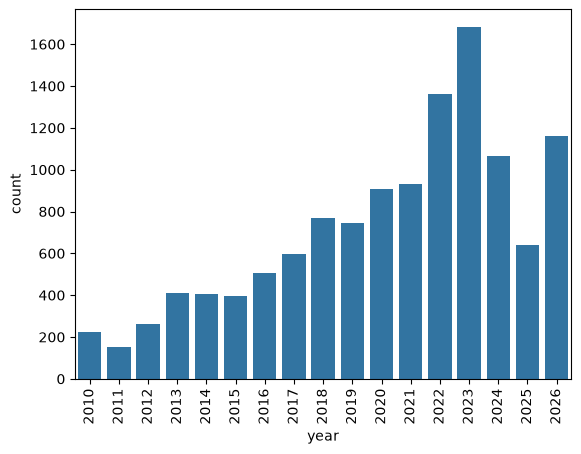

In [21]:
plt.figure()
sns.countplot(data=data, x="year")
plt.xticks(rotation=90)

In [22]:
data[data["year"] > 2020]["osm_id"].nunique()

1426

In [23]:
data["osm_id"].nunique()

2081

#### Полнота по периодам: у скольких сечений заполнены пиковые значения, а не только суточные. Калибровка по пикам содержательнее, чем по суткам.

In [24]:
peak_cols = [
    "peak_hour_morning",
    "peak_hour_evening",
    "vol_morning_0709",
    "vol_morning_hv_0709",
    "vol_evening_1619",
    "vol_evening_hv_1619",
]

peak_fill_rate = (
    data.groupby("osm_id")[peak_cols]
    .apply(lambda g: g.notna().sum() / len(g))
    .reset_index()
)
peak_fill_rate.columns = ["osm_id"] + [f"{c}_fill_rate" for c in peak_cols]
peak_fill_rate

,osm_id,peak_hour_morning_fill_rate,peak_hour_evening_fill_rate,vol_morning_0709_fill_rate,vol_morning_hv_0709_fill_rate,vol_evening_1619_fill_rate,vol_evening_hv_1619_fill_rate
0,-6455414,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
1,-5604751,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,4082887,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
3,4218768,0.909091,0.909091,0.909091,0.000000,0.909091,0.000000
4,4296699,0.727273,0.727273,0.727273,0.545455,0.727273,0.545455
...,...,...,...,...,...,...,...
2076,1396542031,0.666667,0.666667,0.666667,0.000000,0.666667,0.000000
2077,1413501952,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2078,1415342430,0.800000,0.800000,0.800000,0.000000,0.800000,0.000000
2079,1415343204,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667


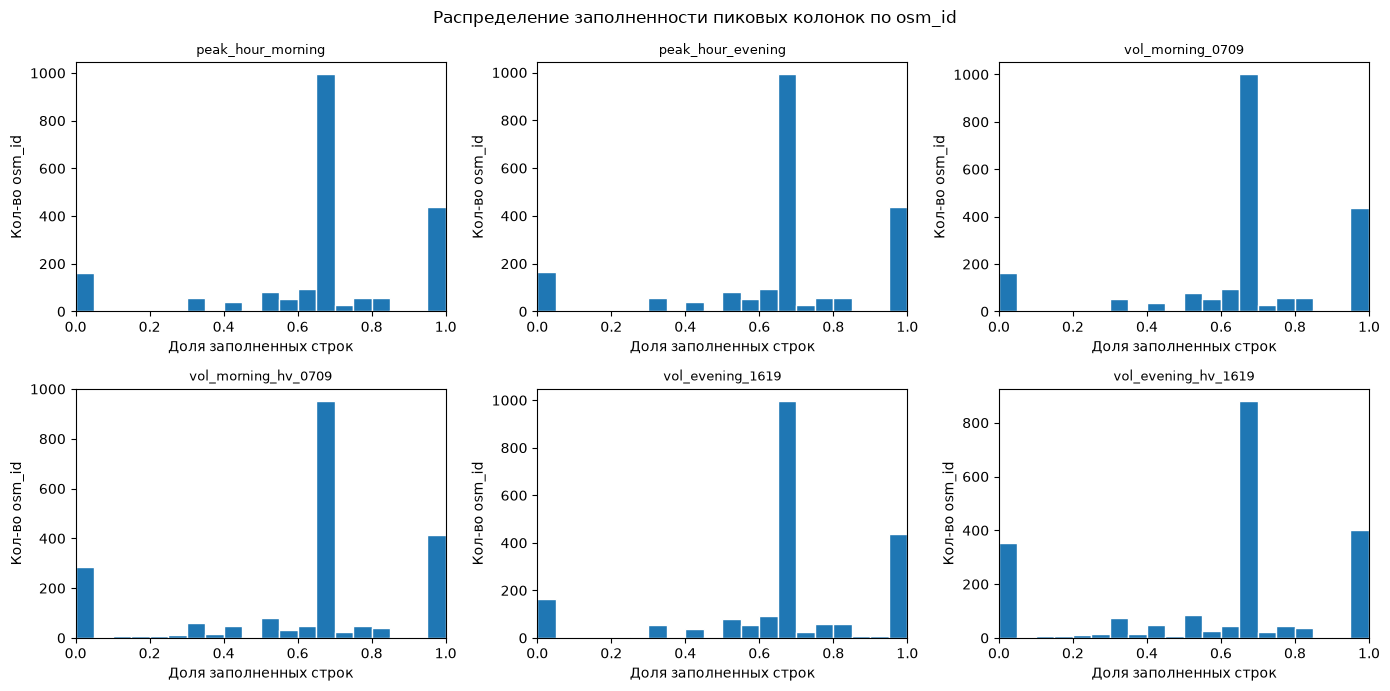

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, peak_cols):
    fill_col = f"{col}_fill_rate"
    ax.hist(peak_fill_rate[fill_col], bins=20, range=(0, 1), edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Доля заполненных строк")
    ax.set_ylabel("Кол-во osm_id")
    ax.set_xlim(0, 1)

fig.suptitle("Распределение заполненности пиковых колонок по osm_id", fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
peak_fill_rate.iloc[:, 1:].mean(axis=0)

peak_hour_morning_fill_rate      0.667720
peak_hour_evening_fill_rate      0.666921
vol_morning_0709_fill_rate       0.668776
vol_morning_hv_0709_fill_rate    0.611946
vol_evening_1619_fill_rate       0.668429
vol_evening_hv_1619_fill_rate    0.585156
dtype: float64

In [27]:
data["osm_id"].unique()

array([244106263, 370743659,  34201206, ..., 237104466, 392881418,
       602740846], shape=(2081,))

In [28]:
data[data["osm_id"] == 370743659].sort_values(by="year")

,object_id,counter_station_id,counter_station_code,counter_station_name,year,section_label,direction_label,counter_type,counting_type,num_channels,channel_list,num_years,year_list,channel_code,aadt_wd,aadt_wd_nsh,aadt_all,aadt_hv_all,peak_hour_morning,peak_hour_evening,tir_all,v85_all,vtma_all,aadt_hv_wd_nsh,vol_morning_0709,vol_morning_hv_0709,vol_daytime_0916,vol_daytime_hv_0916,vol_evening_1619,vol_evening_hv_1619,vol_night_1907,vol_night_hv_1907,period_description,time_days,road_name,highway,municipality,osm_id
5913,5630,972,100457,MONTPELLIER. Boulevard de Strasbourg,2021,Comte Melgueil_Palavas,Comte Melgueil_Palavas,traffic_light,unidirectional,1,{0},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",0,3819.0,3878.0,3601.0,NaN,255 (8h00 - 9h00),378 (17h00 - 18h00),NaN,NaN,NaN,NaN,209.0,NaN,235.0,NaN,338.0,NaN,67.0,NaN,du 01/01/2021 au 31/12/2021,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4552,5633,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Sens cumulés,Sens cumulés,traffic_light,bidirectional,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",Z,4023.0,4074.0,3838.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 01/01/2022 au 23/06/2022,173.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4553,5631,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Comte Melgueil_Palavas,Comte Melgueil_Palavas,traffic_light,bidirectional,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",0,3687.0,3725.0,3533.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,212.0,NaN,NaN,NaN,NaN,NaN,du 01/01/2022 au 23/06/2022,173.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4554,5632,972,100457,MONTPELLIER. Boulevard de Strasbourg,2022,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,bidirectional,3,"{0,1,Z}",11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,336.0,349.0,305.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN,NaN,du 27/09/2022 au 31/12/2022,95.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
2872,5634,972,100457,MONTPELLIER. Boulevard de Strasbourg,2023,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,unidirectional,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,369.0,392.0,337.0,NaN,43 (8h00 - 9h00),30 (17h00 - 18h00),NaN,NaN,NaN,NaN,32.0,NaN,22.0,NaN,28.0,NaN,8.0,NaN,du 01/01/2023 au 31/12/2023,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
4516,7689,83500,98341,MONTPELLIER. Boulevard de Strasbourg (CPEV),2023,Palavas_Orient,Palavas_Orient,spot,unidirectional,1,{0},2,"{2023,2026}",0,379.0,379.0,337.0,NaN,54 (8h00 - 9h00),29 (16h00 - 17h00),NaN,36.0,25.0,NaN,40.0,1.0,22.0,1.0,26.0,0.0,6.0,0.0,du 23/11/2023 au 29/11/2023,6.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
1804,5635,972,100457,MONTPELLIER. Boulevard de Strasbourg,2024,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,unidirectional,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,579.0,593.0,512.0,NaN,83 (8h00 - 9h00),49 (17h00 - 18h00),NaN,NaN,NaN,NaN,60.0,NaN,30.0,NaN,45.0,NaN,11.0,NaN,du 01/01/2024 au 31/12/2024,365.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
1162,5636,972,100457,MONTPELLIER. Boulevard de Strasbourg,2025,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,unidirectional,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,674.0,712.0,604.0,NaN,98 (8h00 - 9h00),58 (17h00 - 18h00),NaN,NaN,NaN,NaN,70.0,NaN,36.0,NaN,53.0,NaN,14.0,NaN,du 01/01/2025 au 31/12/2025,364.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
3,5637,972,100457,MONTPELLIER. Boulevard de Strasbourg,2026,Palavas_Comte Melgueil,Palavas_Comte Melgueil,traffic_light,unidirectional,1,{1},11,"{2016,2017,2018,2019,2020,2021,2022,2023,2024,...",1,754.0,779.0,671.0,NaN,113 (8h00 - 9h00),62 (17h00 - 18h00),NaN,NaN,NaN,NaN,79.0,NaN,39.0,NaN,56.0,NaN,15.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Boulevard de Strasbourg,tertiary,Montpellier,370743659
1137,7690,83500,98341,MO

#### у скольких сечений заполнены суточные значения

In [29]:
daily_cols = [
    "aadt_wd",
    "aadt_wd_nsh",
    "aadt_all",
    "aadt_hv_all",
    "aadt_hv_wd_nsh",
]

daily_fill_rate = (
    data.groupby("osm_id")[daily_cols]
    .apply(lambda g: g.notna().sum() / len(g))
    .reset_index()
)
daily_fill_rate.columns = ["osm_id"] + [f"{c}_fill_rate" for c in daily_cols]
daily_fill_rate

,osm_id,aadt_wd_fill_rate,aadt_wd_nsh_fill_rate,aadt_all_fill_rate,aadt_hv_all_fill_rate,aadt_hv_wd_nsh_fill_rate
0,-6455414,1.0,1.0,1.0,1.000000,1.000000
1,-5604751,1.0,1.0,1.0,1.000000,1.000000
2,4082887,1.0,1.0,1.0,0.000000,0.000000
3,4218768,1.0,1.0,1.0,0.000000,0.000000
4,4296699,1.0,1.0,1.0,0.454545,0.454545
...,...,...,...,...,...,...
2076,1396542031,1.0,1.0,1.0,0.000000,0.000000
2077,1413501952,1.0,1.0,1.0,1.000000,1.000000
2078,1415342430,1.0,1.0,1.0,0.000000,0.000000
2079,1415343204,1.0,1.0,1.0,1.000000,1.000000


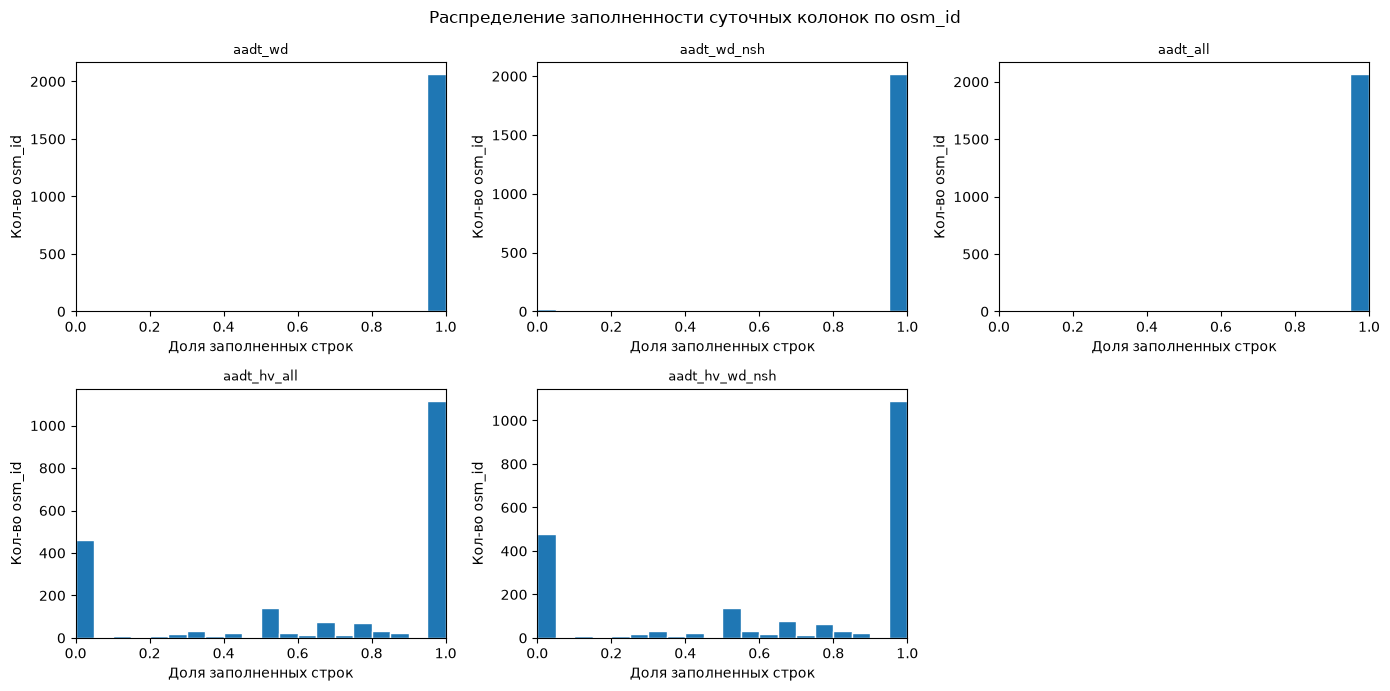

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, daily_cols):
    fill_col = f"{col}_fill_rate"
    ax.hist(daily_fill_rate[fill_col], bins=20, range=(0, 1), edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Доля заполненных строк")
    ax.set_ylabel("Кол-во osm_id")
    ax.set_xlim(0, 1)

axes[-1].set_visible(False)

fig.suptitle("Распределение заполненности суточных колонок по osm_id", fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
daily_fill_rate.iloc[:, 1:].mean(axis=0)

aadt_wd_fill_rate           0.996772
aadt_wd_nsh_fill_rate       0.985598
aadt_all_fill_rate          0.997133
aadt_hv_all_fill_rate       0.674846
aadt_hv_wd_nsh_fill_rate    0.664047
dtype: float64

#### Автоматические / ручные: N / N

In [32]:
osm_types = data.groupby("osm_id").agg(detector_type=("counter_type", "unique"))["detector_type"]

In [33]:
osm_types.value_counts()

detector_type
[spot]                              1843
[permanent]                           56
[traffic_light]                       55
[permanent_bike]                      46
[rotating]                            39
[spot_bike]                            9
[traffic_light, spot]                  1
[traffic_light, spot]                  1
[spot, traffic_light]                  1
[rotating, spot]                       1
[rotating, spot]                       1
[traffic_light, spot]                  1
[traffic_light, spot]                  1
[traffic_light, spot]                  1
[traffic_light, spot]                  1
[spot, traffic_light]                  1
[traffic_light, spot]                  1
[rotating, spot]                       1
[permanent, spot]                      1
[permanent, spot, traffic_light]       1
[spot_bike, spot]                      1
[traffic_light, spot]                  1
[traffic_light, spot]                  1
[permanent, spot]                      1
[t

In [34]:
data[data["osm_id"] == 7984344]

,object_id,counter_station_id,counter_station_code,counter_station_name,year,section_label,direction_label,counter_type,counting_type,num_channels,channel_list,num_years,year_list,channel_code,aadt_wd,aadt_wd_nsh,aadt_all,aadt_hv_all,peak_hour_morning,peak_hour_evening,tir_all,v85_all,vtma_all,aadt_hv_wd_nsh,vol_morning_0709,vol_morning_hv_0709,vol_daytime_0916,vol_daytime_hv_0916,vol_evening_1619,vol_evening_hv_1619,vol_night_1907,vol_night_hv_1907,period_description,time_days,road_name,highway,municipality,osm_id
85,1427,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Sens cumulés,Sens cumulés,traffic_light,bidirectional,3,"{0,1,Z}",2,"{2025,2026}",Z,15193.0,15353.0,14562.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
86,1425,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Boutonnet_Saint Charles,Boutonnet_Saint Charles,traffic_light,bidirectional,3,"{0,1,Z}",2,"{2025,2026}",0,7862.0,7918.0,7500.0,NaN,500 (8h00 - 9h00),519 (17h00 - 18h00),NaN,NaN,NaN,NaN,475.0,NaN,445.0,NaN,516.0,NaN,190.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
87,1426,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2026,Boutonnet_Jugan,Boutonnet_Jugan,traffic_light,bidirectional,3,"{0,1,Z}",2,"{2025,2026}",1,7331.0,7435.0,7062.0,NaN,477 (7h00 - 8h00),472 (16h00 - 17h00),NaN,NaN,NaN,NaN,459.0,NaN,452.0,NaN,464.0,NaN,161.0,NaN,du 01/01/2026 au 02/08/2026,213.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
1206,1423,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2025,Boutonnet_Saint Charles,Boutonnet_Saint Charles,traffic_light,unidirectional,2,"{0,1}",2,"{2025,2026}",0,8149.0,8360.0,7855.0,NaN,521 (8h00 - 9h00),569 (16h00 - 17h00),NaN,NaN,NaN,NaN,495.0,NaN,476.0,NaN,552.0,NaN,196.0,NaN,du 08/07/2025 au 31/12/2025,176.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
1207,1424,83883,109418,MONTPELLIER. Avenue Bouisson Bertrand,2025,Boutonnet_Jugan,Boutonnet_Jugan,traffic_light,unidirectional,2,"{0,1}",2,"{2025,2026}",1,6993.0,6972.0,6783.0,NaN,454 (7h00 - 8h00),449 (14h00 - 15h00),NaN,NaN,NaN,NaN,430.0,NaN,426.0,NaN,422.0,NaN,155.0,NaN,du 07/07/2025 au 31/12/2025,177.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2932,10447,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Sens cumulés,Sens cumulés,spot,bidirectional,3,"{0,1,Z}",3,"{2013,2018,2023}",Z,15350.0,15564.0,14741.0,33.0,NaN,NaN,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 09/06/2023 au 16/06/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2933,10446,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Boutonnet_Lucie,Boutonnet_Lucie,spot,bidirectional,3,"{0,1,Z}",3,"{2013,2018,2023}",1,8541.0,8541.0,8309.0,24.0,520 (7h30 - 8h30),551 (16h15 - 17h15),34.0,36.0,22.0,30.0,487.0,2.0,459.0,2.0,536.0,0.0,229.0,1.0,du 09/06/2023 au 16/06/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
2934,10445,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2023,Lucie_Boutonnet,Lucie_Boutonnet,spot,bidirectional,3,"{0,1,Z}",3,"{2013,2018,2023}",0,6809.0,7023.0,6432.0,9.0,440 (11h30 - 12h30),476 (17h30 - 18h30),9.0,28.0,17.0,13.0,390.0,2.0,411.0,1.0,459.0,0.0,166.0,0.0,du 04/07/2023 au 11/07/2023,7.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
8530,10444,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2018,Sens cumulés,Sens cumulés,spot,bidirectional,3,"{0,1,Z}",3,"{2013,2018,2023}",Z,17148.0,17148.0,16227.0,153.0,NaN,NaN,NaN,NaN,NaN,173.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,du 16/01/2018 au 25/01/2018,9.0,Avenue Bouisson Bertrand,secondary,Montpellier,7984344
8531,10443,317,10490,MONTPELLIER. Avenue Bouisson-Bertrand,2018,Boutonnet_Lucie,Boutonnet_Lucie,spot,bidirectional,3,"{0,1,Z}",3,"{2013,2018,2023}",1,10570.0,10570.0,10016.0,51.0,778 (7h45 - 8h45),731 (17h45 - 18h45),50.0,38.0,26.0,63.0,678.0,5.0,600.0,4.0,715.0,2.0,230.0,2.0,du 16/01/2018 au 25/01/2018,9.0,Avenue Bo

#### Метод измерения: доля автоматических против ручных. Все методы - автоматические

#### Counter type (`counter_type`)

| Value | Description |
|---|---|
| `spot` | Stationary spot counter on a road segment (loop or radar). Continuous long-term monitoring. |
| `permanent` | Permanent motorised-traffic counter. Operates year-round, transmits data in real time. |
| `rotating` | Portable counter (pneumatic tubes or radar). Temporarily installed, then relocated. Short-term surveys. |
| `traffic_light` | Loop detector embedded in the road surface at a signalised intersection. Tied to the traffic-light controller. |
| `permanent_bike` | Permanent bike counter. Same as `permanent` but records cycling only. |
| `spot_bike` | Spot bike counter. Same as `spot` but for cycling only. |

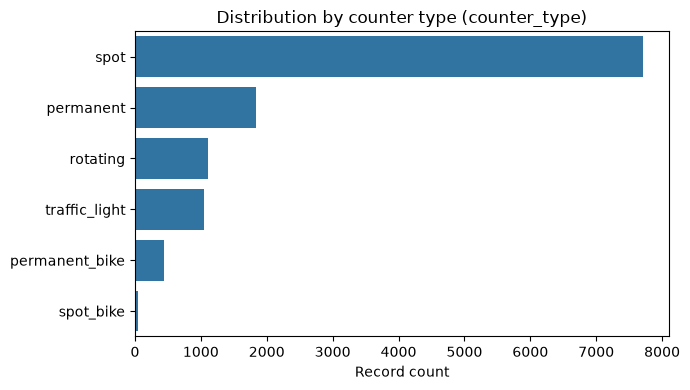

In [35]:
plt.figure(figsize=(7, 4))
order = data["counter_type"].value_counts().index
sns.countplot(data=data, y="counter_type", order=order)
plt.xlabel("Record count")
plt.ylabel("")
plt.title("Distribution by counter type (counter_type)")
plt.tight_layout()
plt.show()

#### Направленность: значения по направлениям движения или суммарные по сечению? Связи в MATSim направленные, и если данные суммарные, при калибровке придётся складывать оба направления модели.

В основном значение трафика суммарные по сечению, но есть и только по направлениям в одну сторону. Распределение представлено ниже

In [36]:
data[["osm_id", "section_label", "direction_label", "counting_type", "num_channels", "channel_list", "channel_code"]]

,osm_id,section_label,direction_label,counting_type,num_channels,channel_list,channel_code
0,244106263,Sens cumulés,Sens cumulés,bidirectional,3,"{0,1,Z}",Z
1,244106263,RM116E2_RM185,RM116E2_RM185,bidirectional,3,"{0,1,Z}",0
2,244106263,RM185_RM116E2,RM185_RM116E2,bidirectional,3,"{0,1,Z}",1
3,370743659,Palavas_Comte Melgueil,Palavas_Comte Melgueil,unidirectional,1,{1},1
4,34201206,Sens cumulés,Sens cumulés,bidirectional,3,"{0,1,Z}",Z
...,...,...,...,...,...,...,...
12206,295849662,Marès-Pérouse,Marès-Pérouse,bidirectional,3,"{0,1,Z}",1
12207,295849662,Pérouse-Marès,Pérouse-Marès,bidirectional,3,"{0,1,Z}",0
12208,27228047,Sens cumulés,Sens cumulés,bidirectional,3,"{0,1,Z}",Z
12209,27228047,Impasse-Lepine,Impasse-Lepine,bidirectional,3,"{0,1,Z}",0


In [37]:
data["counting_type"].value_counts()

counting_type
bidirectional     10326
unidirectional     1853
NR                   32
Name: count, dtype: int64

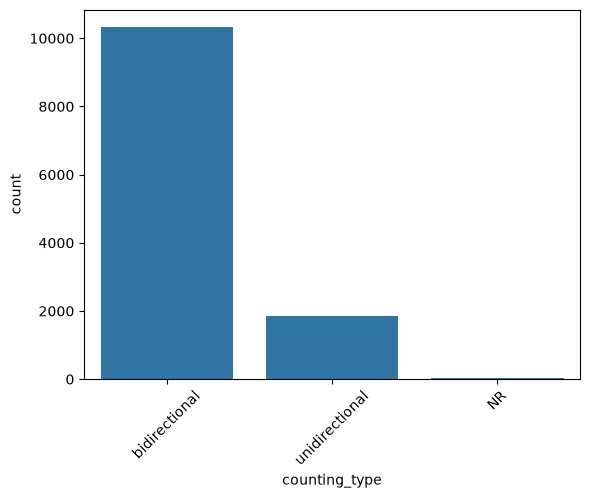

In [38]:
plt.figure()
sns.countplot(data=data, x="counting_type")
plt.xticks(rotation=45)
plt.show()

#### Географическое покрытие: нанесите сечения на карту метрополии. Есть ли периферийные коммуны или всё сосредоточено в ядре Монпелье? Это определит, где модель будет калиброванной, а где — нет.

In [39]:
import requests
import folium
import time
from tqdm.notebook import tqdm

HEADERS = {"User-Agent": "matsim-analysis/1.0"}
BATCH = 200
RETRY_SLEEP = 10

osm_ids = data["osm_id"].unique().tolist()
batches = range(0, len(osm_ids), BATCH)

coords = {}
with tqdm(total=len(osm_ids), desc="Overpass API", unit="osm_id") as pbar:
    for i in batches:
        batch = osm_ids[i : i + BATCH]
        batch_ids = ",".join(str(x) for x in batch)
        query = f"[out:json];way(id:{batch_ids});out center;"

        for attempt in range(3):
            try:
                r = requests.post(
                    "https://overpass-api.de/api/interpreter",
                    data={"data": query},
                    headers=HEADERS,
                    timeout=60,
                )
                if r.status_code != 200 or not r.text.strip():
                    pbar.set_postfix(status=f"HTTP {r.status_code}, retry {attempt+1}")
                    time.sleep(RETRY_SLEEP)
                    continue
                for el in r.json().get("elements", []):
                    if "center" in el:
                        coords[el["id"]] = (el["center"]["lat"], el["center"]["lon"])
                pbar.set_postfix(status="ok", coords=len(coords))
                break
            except Exception as e:
                pbar.set_postfix(status=f"err: {e}, retry {attempt+1}")
                time.sleep(RETRY_SLEEP)

        pbar.update(len(batch))
        time.sleep(2)

print(f"Получено координат: {len(coords)} из {len(osm_ids)}")

Overpass API:   0%|          | 0/2081 [00:00<?, ?osm_id/s]

Получено координат: 1267 из 2081


In [40]:
commune_colors = {c: color for c, color in zip(
    data["municipality"].unique(),
    [f"#{hash(c) & 0xFFFFFF:06x}" for c in data["municipality"].unique()]
)}

m = folium.Map(location=[43.61, 3.88], zoom_start=11, tiles="CartoDB positron")

plotted = set()
for _, row in data[["osm_id", "municipality"]].drop_duplicates("osm_id").iterrows():
    oid = row["osm_id"]
    if oid not in coords:
        continue
    lat, lon = coords[oid]
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color=commune_colors.get(row["municipality"], "#888888"),
        fill=True,
        fill_opacity=0.7,
        popup=f"{oid} — {row['municipality']}",
        tooltip=row["municipality"],
    ).add_to(m)

m.save("map_coverage.html")
m

In [41]:
data["municipality"].nunique()

41

In [42]:
data["municipality"].value_counts()

municipality
Montpellier                  7823
Castelnau-le-Lez              441
Lattes                        396
Saint-Jean-de-Védas           330
Le Crès                       252
Villeneuve-lès-Maguelone      206
Pignan                        203
Lavérune                      197
Fabrègues                     196
Vendargues                    191
Grabels                       189
Montferrier-sur-Lez           149
Baillargues                   144
Castries                      141
Cournonterral                 127
Juvignac                      121
Saint-Drézéry                 120
Cournonsec                    113
Pérols                        103
Jacou                          97
Clapiers                       90
Saint-Geniès-des-Mourgues      76
Montaud                        75
Saussan                        73
Saint-Brès                     56
Saint-Georges-d'Orques         52
Murviel-lès-Montpellier        52
Sussargues                     52
Restinclières                  45
B

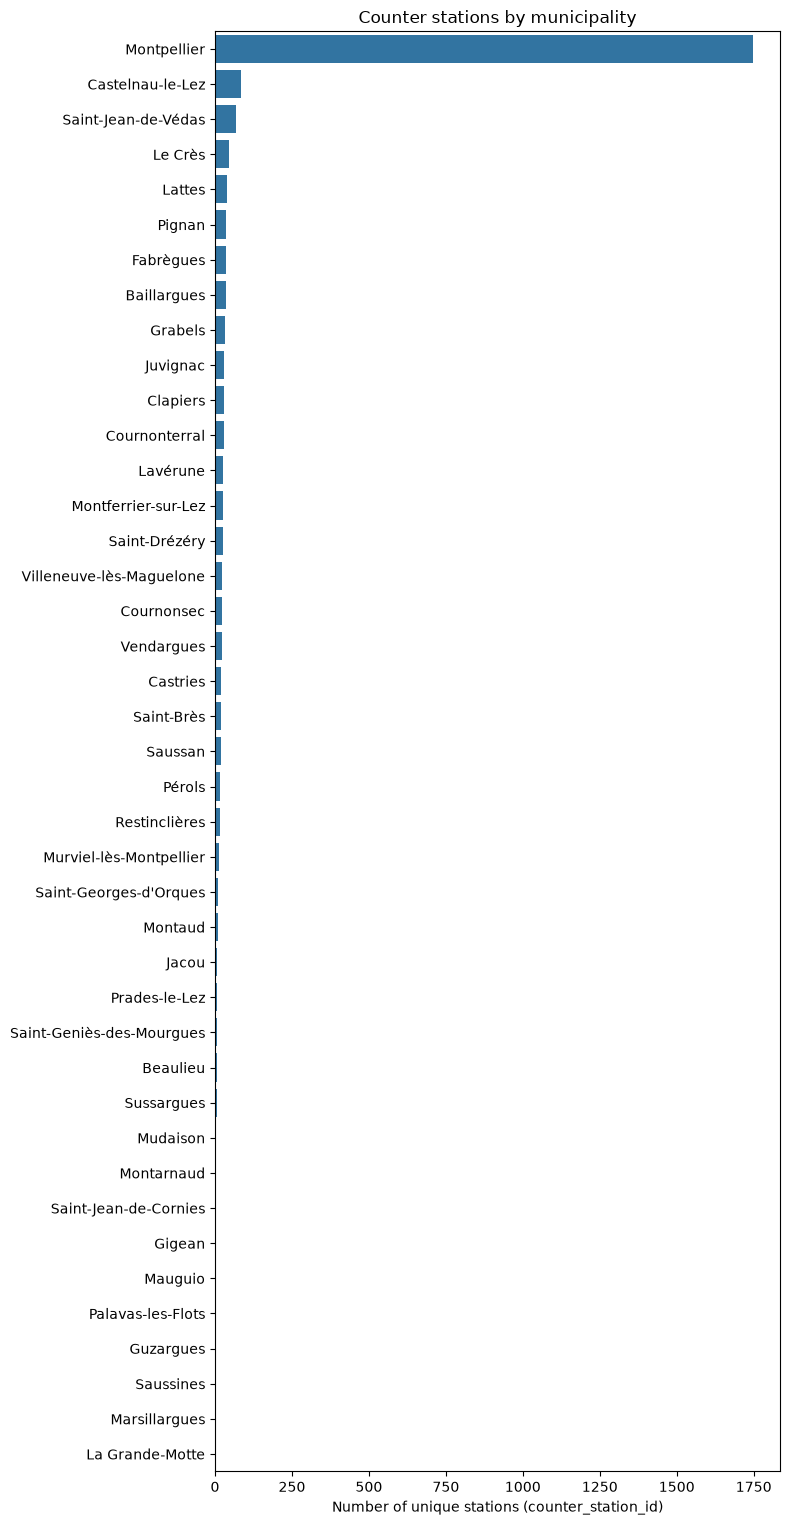

In [43]:
stations_per_commune = (
    data.drop_duplicates("counter_station_id")["municipality"]
    .value_counts()
    .reset_index()
)
stations_per_commune.columns = ["municipality", "count"]

plt.figure(figsize=(8, len(stations_per_commune) * 0.35 + 1))
sns.barplot(data=stations_per_commune, y="municipality", x="count", order=stations_per_commune["municipality"])
plt.xlabel("Number of unique stations (counter_station_id)")
plt.ylabel("")
plt.title("Counter stations by municipality")
plt.tight_layout()
plt.show()